# Week 3 — Go nuts with your LLM: paths, centrality, mixing, cliques

Working notebook for course 02805, week 3's free-form "go nuts" post. Same shared
Marvel Comics hyperlink network as [week1.html](posts/week1.html) and
[week2.html](posts/week2.html), pulled fresh from `data_1/` plus the community
labels already computed for `explore.html` in `assets/data/explore_data.json`.

Covers all four of this week's required tools — paths, centrality, mixing patterns,
and cliques — each pointed at one focused question, with null models used to check
whether the centrality and mixing findings are real structure or just what you'd
expect from degree/label composition alone.

## Setup: load the shared Marvel network + community labels

In [1]:
import json
import random
from itertools import combinations

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# Site palette, lifted from assets/css/style.css, matching week1/week2's dark comic-book theme.
BG = "#120014"
PANEL = "#1c0722"
GRID = "#3a1f3f"
BORDER = "#4a2450"
TEXT = "#fdf1fb"
TEXT_DIM = "#cba8c9"
HOTPINK = "#ff2e9c"
MAGENTA = "#c400ff"
CYAN = "#00e5ff"
YELLOW = "#ffe14d"
MUTED = "#6b5670"

CYAN_MAGENTA = mcolors.LinearSegmentedColormap.from_list("site_cyan_magenta", [CYAN, MAGENTA, HOTPINK])

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": BORDER,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.9,
    "text.color": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "font.weight": "bold",
    "legend.facecolor": PANEL,
    "legend.edgecolor": BORDER,
    "legend.labelcolor": TEXT,
    "savefig.facecolor": BG,
})

In [2]:
edges_df = pd.read_csv("data_1/week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
nodes_df = pd.read_csv("data_1/week1_nodes.tsv", sep="\t", comment="#", header=0)

G_directed = nx.DiGraph()
G_directed.add_nodes_from(nodes_df["node_id"])
G_directed.add_edges_from(edges_df[["source", "target"]].itertuples(index=False, name=None))

G_marvel = nx.Graph(G_directed)
G_marvel.remove_edges_from(nx.selfloop_edges(G_marvel))
n_marvel, m_marvel = G_marvel.number_of_nodes(), G_marvel.number_of_edges()

# community labels + display names, already computed for explore.html
explore = json.load(open("assets/data/explore_data.json", encoding="utf-8"))
clabel = {n["id"]: n["clabel"] for n in explore["nodes"]}
name_of = {n["id"]: n["name"] for n in explore["nodes"]}
nx.set_node_attributes(G_marvel, clabel, "clabel")

components = sorted(nx.connected_components(G_marvel), key=len, reverse=True)
G_gc = G_marvel.subgraph(components[0]).copy()

print(f"Undirected: {n_marvel} nodes, {m_marvel} edges")
print(f"Giant component: {G_gc.number_of_nodes()} nodes ({100*G_gc.number_of_nodes()/n_marvel:.1f}%), {len(components)} components total")

Undirected: 303 nodes, 1434 edges
Giant component: 277 nodes (91.4%), 19 components total


## 3.2 — Paths: how many hops from Spider-Man?

BFS from the network's biggest hub, then a quick look at where the graph's actual
diameter (the real "six degrees" case) lives instead.

In [3]:
source = "Spider-Man"
dist = nx.single_source_shortest_path_length(G_gc, source)
ecc_spidey = max(dist.values())
dist_counts = pd.Series(list(dist.values())).value_counts().sort_index()
farthest = [name_of.get(k, k) for k, v in dist.items() if v == ecc_spidey]

print(f"Eccentricity of {source} in the giant component: {ecc_spidey}")
print(dist_counts)
print(f"\nFarthest characters ({ecc_spidey} hops from {source}): {farthest}")

diam_gc = nx.diameter(G_gc)
avg_dist_gc = nx.average_shortest_path_length(G_gc)
radius = nx.radius(G_gc)
ecc_all = nx.eccentricity(G_gc)
center_nodes = [name_of.get(k, k) for k, v in ecc_all.items() if v == radius]
periphery_nodes = [name_of.get(k, k) for k, v in ecc_all.items() if v == diam_gc]

print(f"\nGiant component diameter: {diam_gc}, avg shortest path: {avg_dist_gc:.3f}, radius: {radius}")
print(f"Center node(s) (eccentricity == radius): {center_nodes}")
print(f"Periphery node(s) (eccentricity == diameter): {periphery_nodes}")

Eccentricity of Spider-Man in the giant component: 3
0      1
1    106
2    152
3     18
Name: count, dtype: int64

Farthest characters (3 hops from Spider-Man): ['Kid Colt', 'Mahr Vehl', 'Justice (New Universe)', 'Makkari (character)', 'Marvel Boy (Robert Grayson)', 'Skull the Slayer', 'Citizen V', 'G. W. Bridge', 'Magician (Marvel Comics)', 'The Witness (character)', 'The Union (Marvel)', 'Mark Hazzard: Merc', 'Starr the Slayer', 'Detroit Steel', 'Redneck (comics)', 'Box (comics)', 'Thena', 'Force (comics)']



Giant component diameter: 6, avg shortest path: 2.674, radius: 3
Center node(s) (eccentricity == radius): ['Spider-Man']
Periphery node(s) (eccentricity == diameter): ['Mahr Vehl', 'Mark Hazzard: Merc', 'Redneck (comics)', 'Starr the Slayer', 'The Witness (character)']


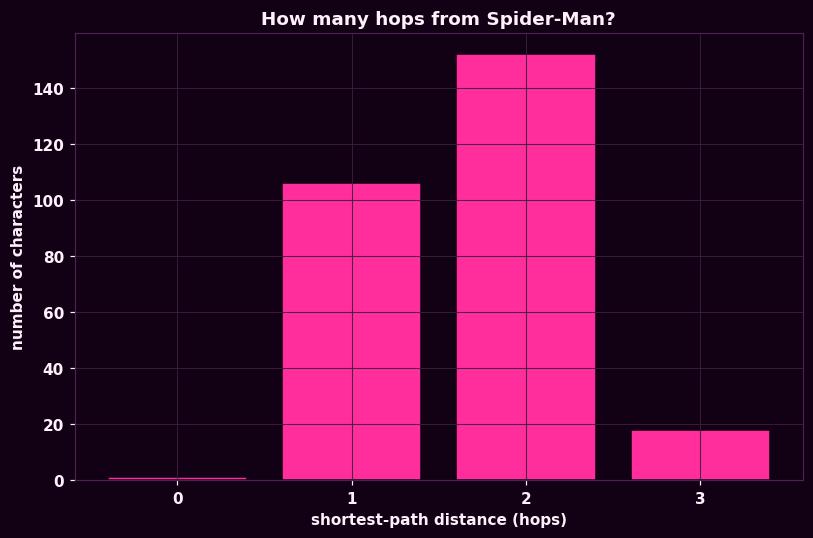

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(dist_counts.index, dist_counts.values, color=HOTPINK, edgecolor=BG)
ax.set_title(f"How many hops from {source}?", color=TEXT)
ax.set_xlabel("shortest-path distance (hops)")
ax.set_ylabel("number of characters")
ax.set_xticks(dist_counts.index)
plt.tight_layout()
plt.savefig("assets/img/fig_six_degrees.png", dpi=150)
plt.show()

## 3.3/3.6 — Centrality: harmonic closeness vs. degree, checked against a null model

Harmonic closeness centrality handles the network's 19 disconnected components
natively (unlike plain closeness, which needs everyone mutually reachable). We rank
every character by it and compare to plain degree rank to find whoever's position
punches furthest above its weight — then use a degree-preserving null model
(random double-edge-swap rewiring) to check whether that's a real structural fact
or just something you'd expect from *any* node with that degree.

In [5]:
harmonic = nx.harmonic_centrality(G_marvel)
degree = dict(G_marvel.degree())

df = pd.DataFrame({"node": list(G_marvel.nodes())}).assign(
    degree=lambda d: d["node"].map(degree),
    harmonic=lambda d: d["node"].map(harmonic),
    clabel=lambda d: d["node"].map(clabel),
    name=lambda d: d["node"].map(name_of),
)
df["degree_rank"] = df["degree"].rank(ascending=False, method="min")
df["harmonic_rank"] = df["harmonic"].rank(ascending=False, method="min")
df["rank_gap"] = df["degree_rank"] - df["harmonic_rank"]  # positive = more central than degree alone suggests

top_surprise = df.sort_values("rank_gap", ascending=False).head(8)
top_surprise[["name", "degree", "degree_rank", "harmonic", "harmonic_rank", "rank_gap", "clabel"]]

,name,degree,degree_rank,harmonic,harmonic_rank,rank_gap,clabel
225,Scorpio (Marvel Comics),2,243.0,114.000000,129.0,114.0,Spider-Verse
83,Enigma (Marvel Comics),1,269.0,108.666667,163.0,106.0,Spider-Verse
114,Helix (Marvel Comics),1,269.0,108.666667,163.0,106.0,Spider-Verse
178,Phil Grayfield,1,269.0,108.666667,163.0,106.0,Spider-Verse
272,Thunderclap (comics),1,269.0,108.666667,163.0,106.0,Spider-Verse
84,Ethan Edwards,1,269.0,108.666667,163.0,106.0,Spider-Verse
236,Silhouette (comics),2,243.0,111.250000,150.0,93.0,Heroes for Hire & Defenders
85,Fabio Medina,3,212.0,114.000000,130.0,82.0,X-Men


In [6]:
surprise_node = top_surprise.iloc[0]["node"]
surprise_deg_rank = int(top_surprise.iloc[0]["degree_rank"])
surprise_har_rank_real = int(top_surprise.iloc[0]["harmonic_rank"])
print(f"Null-model test on: {name_of.get(surprise_node, surprise_node)}")
print(f"  neighbors: {[(name_of.get(x, x), degree[x]) for x in G_marvel.neighbors(surprise_node)]}")
print(f"  degree rank {surprise_deg_rank}, harmonic rank {surprise_har_rank_real}")

n_swaps_trials = 200
null_ranks = []
rng = random.Random(RNG_SEED)
for _ in range(n_swaps_trials):
    G_rand = G_marvel.copy()
    try:
        nx.double_edge_swap(G_rand, nswap=4 * m_marvel, max_tries=40 * m_marvel, seed=rng.randint(0, 10**9))
    except nx.NetworkXError:
        pass
    har_rand = nx.harmonic_centrality(G_rand)
    ranks = pd.Series(har_rand).rank(ascending=False, method="min")
    null_ranks.append(ranks[surprise_node])

null_ranks = np.array(null_ranks)
z = (surprise_har_rank_real - null_ranks.mean()) / null_ranks.std()
print(f"\nNull (degree-preserving) harmonic rank: mean={null_ranks.mean():.1f}, std={null_ranks.std():.1f}")
print(f"Real harmonic rank = {surprise_har_rank_real}; z-score vs null = {z:.2f}")

Null-model test on: Scorpio (Marvel Comics)
  neighbors: [('Spider-Man', 106), ('Wolverine (character)', 63)]
  degree rank 243, harmonic rank 129



Null (degree-preserving) harmonic rank: mean=238.1, std=36.3
Real harmonic rank = 129; z-score vs null = -3.01


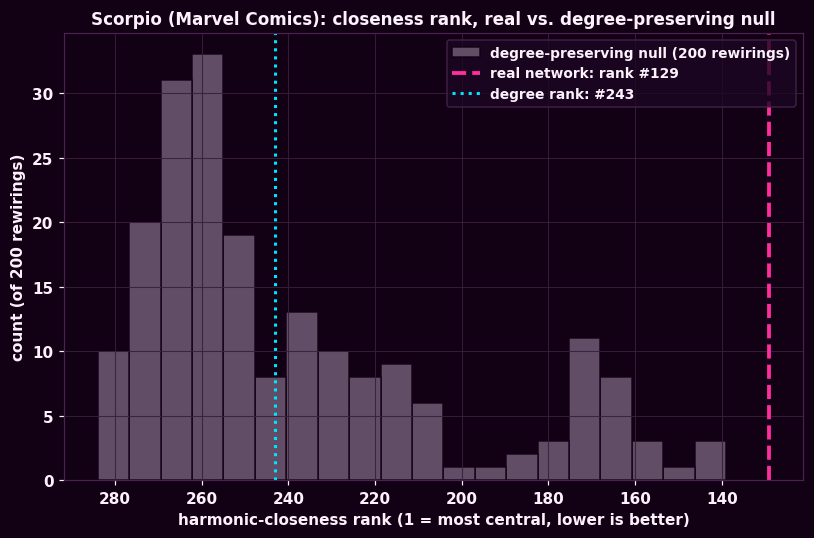

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(null_ranks, bins=20, color=MUTED, edgecolor=BG, alpha=0.9, label="degree-preserving null (200 rewirings)")
ax.axvline(surprise_har_rank_real, color=HOTPINK, lw=2.5, ls="--", label=f"real network: rank #{surprise_har_rank_real}")
ax.axvline(surprise_deg_rank, color=CYAN, lw=2, ls=":", label=f"degree rank: #{surprise_deg_rank}")
ax.set_title(f"{name_of.get(surprise_node, surprise_node)}: closeness rank, real vs. degree-preserving null", color=TEXT, fontsize=11)
ax.set_xlabel("harmonic-closeness rank (1 = most central, lower is better)")
ax.set_ylabel("count (of 200 rewirings)")
ax.invert_xaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/img/fig_centrality_null.png", dpi=150)
plt.show()

## 3.7 — Mixing patterns: degree assortativity + community homophily

Degree assortativity asks "do hubs link to hubs?"; homophily asks "do same-team
characters link to each other more than chance?" We test the second with a label-
shuffle null: scramble which team label sits on which node, keep the network itself
fixed, and see what same-team edge fraction that produces with no real team
structure at all.

In [8]:
r = nx.degree_assortativity_coefficient(G_marvel)
print(f"Degree assortativity coefficient: {r:.4f}")

def same_label_fraction(G, labels):
    same = sum(1 for u, v in G.edges() if labels[u] == labels[v])
    return same / G.number_of_edges()

labels_true = nx.get_node_attributes(G_marvel, "clabel")
observed_frac = same_label_fraction(G_marvel, labels_true)

nodes_list = list(G_marvel.nodes())
label_values = [labels_true[n] for n in nodes_list]
rng2 = random.Random(RNG_SEED)
n_shuffles = 1000
null_fracs = np.empty(n_shuffles)
for i in range(n_shuffles):
    shuffled = label_values[:]
    rng2.shuffle(shuffled)
    null_fracs[i] = same_label_fraction(G_marvel, dict(zip(nodes_list, shuffled)))

z_mix = (observed_frac - null_fracs.mean()) / null_fracs.std()
print(f"Observed same-community edge fraction: {observed_frac:.4f}")
print(f"Null (shuffled labels): mean={null_fracs.mean():.4f}, std={null_fracs.std():.4f}")
print(f"z-score: {z_mix:.2f}")

Degree assortativity coefficient: -0.0977


Observed same-community edge fraction: 0.5363
Null (shuffled labels): mean=0.1171, std=0.0097
z-score: 43.04


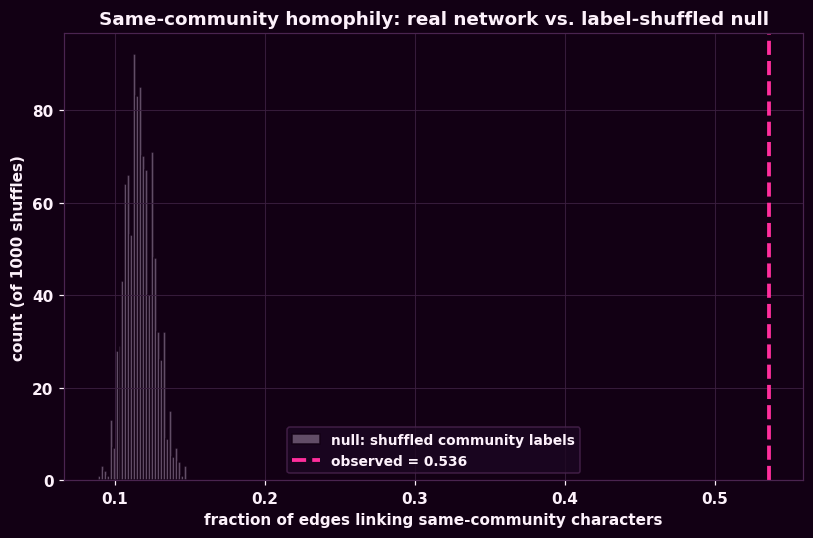

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(null_fracs, bins=30, color=MUTED, edgecolor=BG, alpha=0.9, label="null: shuffled community labels")
ax.axvline(observed_frac, color=HOTPINK, lw=2.5, ls="--", label=f"observed = {observed_frac:.3f}")
ax.set_title("Same-community homophily: real network vs. label-shuffled null", color=TEXT, fontsize=12)
ax.set_xlabel("fraction of edges linking same-community characters")
ax.set_ylabel("count (of 1000 shuffles)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/img/fig_mixing_homophily.png", dpi=150)
plt.show()

## 3.8 — Cliques: how far does that team loyalty go locally?

A maximal clique is a set of characters who are *all* pairwise linked. We find every
maximal clique, look at what the largest ones are made of, and re-run the same
label-shuffle homophily test restricted to pairs inside cliques of size 4+.

In [10]:
cliques = list(nx.find_cliques(G_marvel))
clique_sizes = [len(c) for c in cliques]
clique_number = max(clique_sizes)
size_counts = pd.Series(clique_sizes).value_counts().sort_index()

print(f"Total maximal cliques: {len(cliques)}, clique number (largest): {clique_number}")
print(size_counts)

largest_cliques = [c for c in cliques if len(c) == clique_number]
print(f"\nNumber of maximum-size ({clique_number}) cliques: {len(largest_cliques)}")
for c in largest_cliques:
    print([name_of.get(n, n) for n in c])

Total maximal cliques: 917, clique number (largest): 8
1     17
2    164
3    332
4    251
5    120
6     25
7      2
8      6
Name: count, dtype: int64

Number of maximum-size (8) cliques: 6
['Cyclops (Marvel Comics)', 'Wolverine (character)', 'Betsy Braddock', 'Emma Frost', 'Jean Grey', 'Rachel Summers', 'Cable (character)', 'Phoenix (Guardians of the Galaxy)']
['Cyclops (Marvel Comics)', 'Wolverine (character)', 'Betsy Braddock', 'Emma Frost', 'Jean Grey', 'Rachel Summers', 'Cable (character)', 'Northstar (character)']
['Cyclops (Marvel Comics)', 'Wolverine (character)', 'Betsy Braddock', 'Emma Frost', 'Jean Grey', 'Rachel Summers', 'Cable (character)', 'Jubilee (character)']
['Cyclops (Marvel Comics)', 'Wolverine (character)', 'Betsy Braddock', 'Emma Frost', 'Jean Grey', 'Rachel Summers', 'Storm (Marvel Comics)', 'Phoenix (Guardians of the Galaxy)']
['Cyclops (Marvel Comics)', 'Wolverine (character)', 'Betsy Braddock', 'Emma Frost', 'Jean Grey', 'Rachel Summers', 'Storm (Marvel Com

In [11]:
def clique_same_label_fraction(clique_list, labels):
    same, total = 0, 0
    for c in clique_list:
        for u, v in combinations(c, 2):
            total += 1
            same += labels[u] == labels[v]
    return same / total if total else float("nan")

big_cliques = [c for c in cliques if len(c) >= 4]
observed_clique_frac = clique_same_label_fraction(big_cliques, labels_true)

null_clique_fracs = np.empty(n_shuffles)
for i in range(n_shuffles):
    shuffled = label_values[:]
    rng2.shuffle(shuffled)
    null_clique_fracs[i] = clique_same_label_fraction(big_cliques, dict(zip(nodes_list, shuffled)))

z_clique = (observed_clique_frac - null_clique_fracs.mean()) / null_clique_fracs.std()
print(f"Cliques of size >= 4: {len(big_cliques)}")
print(f"Observed same-community pair fraction within them: {observed_clique_frac:.4f}")
print(f"Null: mean={null_clique_fracs.mean():.4f}, std={null_clique_fracs.std():.4f}")
print(f"z-score: {z_clique:.2f}")

Cliques of size >= 4: 404
Observed same-community pair fraction within them: 0.5023
Null: mean=0.1159, std=0.0212
z-score: 18.25


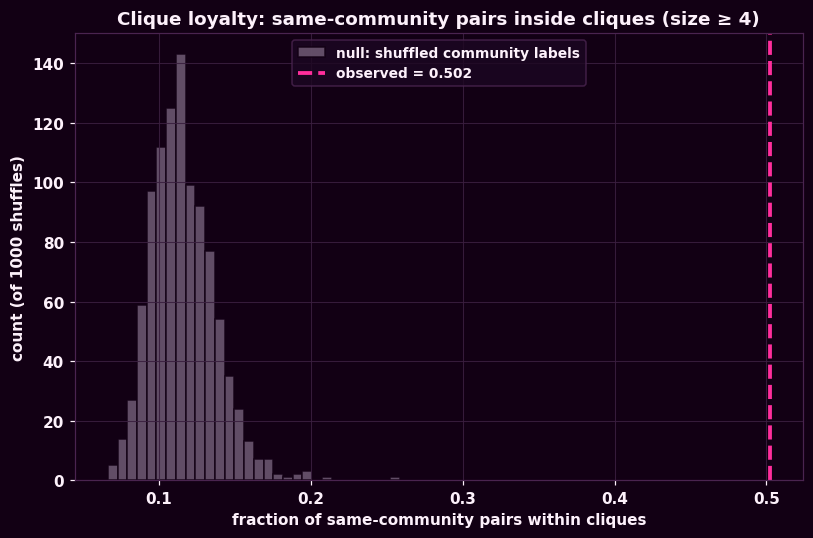

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(null_clique_fracs, bins=30, color=MUTED, edgecolor=BG, alpha=0.9, label="null: shuffled community labels")
ax.axvline(observed_clique_frac, color=HOTPINK, lw=2.5, ls="--", label=f"observed = {observed_clique_frac:.3f}")
ax.set_title("Clique loyalty: same-community pairs inside cliques (size ≥ 4)", color=TEXT, fontsize=12)
ax.set_xlabel("fraction of same-community pairs within cliques")
ax.set_ylabel("count (of 1000 shuffles)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/img/fig_clique_homophily.png", dpi=150)
plt.show()

## Wrap-up

Written up as [week3.html](posts/week3.html): Spider-Man's 3-hop reach (not six —
that's the *diameter*, between two obscure periphery characters instead), Scorpio's
degree-defying closeness rank surviving a degree-preserving null model, and two
independent label-shuffle tests (mixing + cliques) both landing at enormous z-scores
for team loyalty.